In [1]:
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import scanpy as sc
import sklearn
import numpy as np
import pandas as pd
import statsmodels as stat
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import gseapy as gp
import os
import tarfile
import anndata as adata
import glob

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
os.makedirs("../Data/GSE111893/", exist_ok=True)
!curl -C - -L "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE111893&format=file" -o "../Data/GSE111893/GSE111893_RAW.tar"

** Resuming transfer from byte position 2803312640
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 2673M    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


In [3]:
tar_path = "../Data/GSE111893/GSE111893_RAW.tar"
extract_dir = "../Data/GSE111893/extracted_raw/"
os.makedirs(extract_dir, exist_ok=True)
with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_dir)
extracted_files = os.listdir(extract_dir)
print(f"Success! Extracted {len(extracted_files)} files.")
print("Sample files:", extracted_files[:5])

Success! Extracted 4 files.
Sample files: ['GSM3044498_CB_CB35_SC.txt.gz', 'GSM3044497_JMML_ID5_SC.txt.gz', 'GSM3044495_JMML_ID1_SC.txt.gz', 'GSM3044500_CB_CB37_SC.txt.gz']


In [4]:
extracted_dir = "../Data/GSE111893/extracted_raw/"
file_paths = glob.glob(os.path.join(extracted_dir, "*.txt.gz"))

adatas = []

print("Loading and parsing single-cell sample files...")

for filepath in file_paths:
    filename = os.path.basename(filepath)
    print(f"Reading: {filename}")
    df = pd.read_csv(filepath, sep="\t", index_col=0)
    sample_adata = sc.AnnData(df.T)
    if "JMML" in filename:
        sample_adata.obs["condition"] = "JMML"
    else:
        sample_adata.obs["condition"] = "Control"
    sample_id = filename.split("_SC.txt.gz")[0]
    sample_adata.obs["sample_id"] = sample_id
    adatas.append(sample_adata)

adata = sc.concat(adatas, merge="unique")
adata.var_names_make_unique()

print("\nSuccessfully built single-cell AnnData object!")
print(
    f"Total cells: {adata.n_obs} | Total genes: {adata.n_vars}"
)
print("Condition breakdown:")
print(adata.obs["condition"].value_counts())

Loading and parsing single-cell sample files...
Reading: GSM3044498_CB_CB35_SC.txt.gz
Reading: GSM3044497_JMML_ID5_SC.txt.gz
Reading: GSM3044495_JMML_ID1_SC.txt.gz
Reading: GSM3044500_CB_CB37_SC.txt.gz

Successfully built single-cell AnnData object!
Total cells: 17547 | Total genes: 32738
Condition breakdown:
condition
Control    10881
JMML        6666
Name: count, dtype: int64


In [5]:
signature_file = "../Results/signatures/GSE147523_gene_symbols_only.txt"

with open(signature_file, "r") as f:
    jmml_signature = [line.strip() for line in f.readlines()]

valid_signature_genes = [gene for gene in jmml_signature if gene in adata.var_names]
print(f"Found {len(valid_signature_genes)} / {len(jmml_signature)} signature genes in single-cell matrix.")

Found 131 / 218 signature genes in single-cell matrix.


In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.score_genes(
    adata, 
    gene_list=valid_signature_genes, 
    score_name="JMML_bulk_signature_score"
)

/Users/alexchen/anaconda3/envs/jmml_transcriptomics/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/Users/alexchen/anaconda3/envs/jmml_transcriptomics/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:384: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


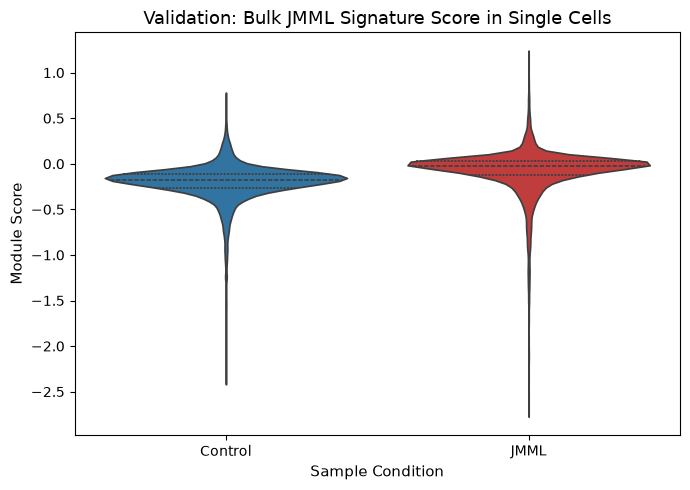

In [7]:
plt.figure(figsize=(7, 5))
sns.violinplot(
    data=adata.obs, 
    x="condition", 
    y="JMML_bulk_signature_score", 
    palette={"JMML": "#d62728", "Control": "#1f77b4"},
    inner="quartile"
)
plt.title("Validation: Bulk JMML Signature Score in Single Cells", fontsize=13)
plt.xlabel("Sample Condition", fontsize=11)
plt.ylabel("Module Score", fontsize=11)

plt.tight_layout()
plt.savefig("../Results/figures/GSE111893_signature_validation_violin.png", dpi=300)
plt.show()

In [ ]:
# Scanpy Standard workflow

